In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('uci breast cancer dataset.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [8]:
df.drop(['id', 'Unnamed: 32'],axis=1,inplace=True)

In [9]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
df.duplicated().sum()

0

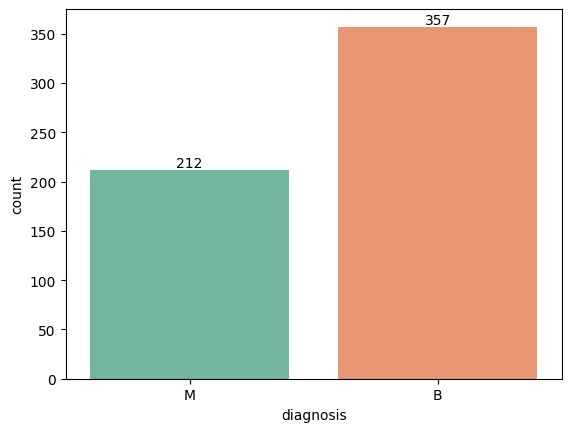

In [12]:
ax = sns.countplot(x = df['diagnosis'], data =df, palette='Set2')
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
               (bar.get_x() + bar.get_width() / 2,height),
               ha = 'center',
               va='bottom')


In [13]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [14]:
df.shape

(569, 31)

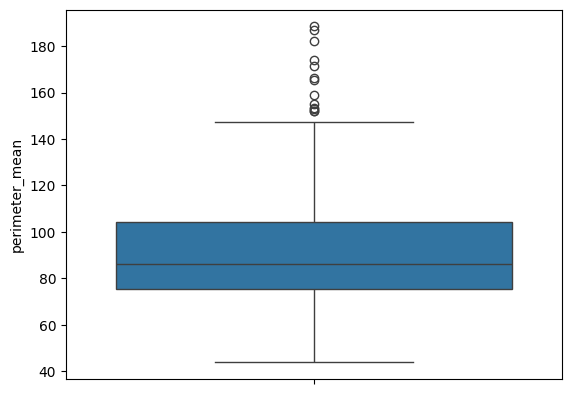

In [15]:
sns.boxplot(y= df['perimeter_mean'])
plt.show()

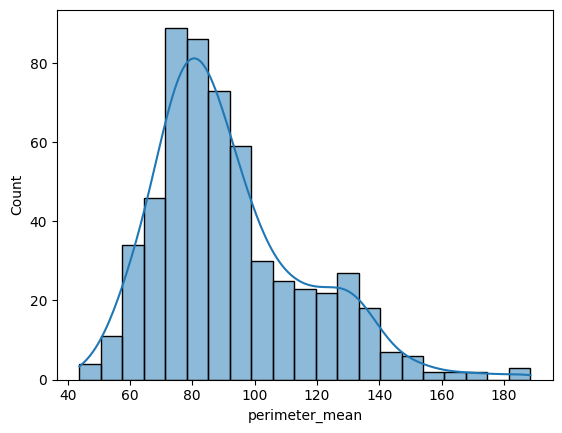

In [18]:
sns.histplot(x= df['perimeter_mean'],kde = True)
plt.show()

In [20]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [21]:
x = df.drop('diagnosis',axis=1)
y = df['diagnosis']

In [23]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_scaled = std.fit_transform(x)

In [30]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
sm = SMOTETomek(smote=SMOTE(k_neighbors=5),random_state=100)
newx,newy = sm.fit_resample(x_scaled,y)

In [32]:
newy.value_counts()

diagnosis
M    355
B    355
Name: count, dtype: int64

In [33]:
xtrain,xtest,ytrain,ytest = train_test_split (newx,newy,test_size=0.2,random_state=42)

In [34]:
rf = RandomForestClassifier()
rf.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
rf.score(xtrain,ytrain)

1.0

In [36]:
rf.score(xtest,ytest)

0.971830985915493

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
st = StratifiedKFold()
model =cross_val_score(rf,newx,newy, cv=st)

In [44]:
model.mean()

0.9774647887323944

In [45]:
pred = rf.predict(xtest)
pred

array(['B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M',
       'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M',
       'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'M', 'M',
       'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B', 'M', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B',
       'M', 'M', 'M', 'M', 'B', 'M', 'M', 'M', 'M', 'M', 'M', 'M'],
      dtype=object)

In [46]:
print('Accuracy Score: ',accuracy_score(ytest,pred))

Accuracy Score:  0.971830985915493


In [47]:
print('Classification Report: \n',classification_report(ytest,pred))

Classification Report: 
               precision    recall  f1-score   support

           B       0.97      0.97      0.97        68
           M       0.97      0.97      0.97        74

    accuracy                           0.97       142
   macro avg       0.97      0.97      0.97       142
weighted avg       0.97      0.97      0.97       142



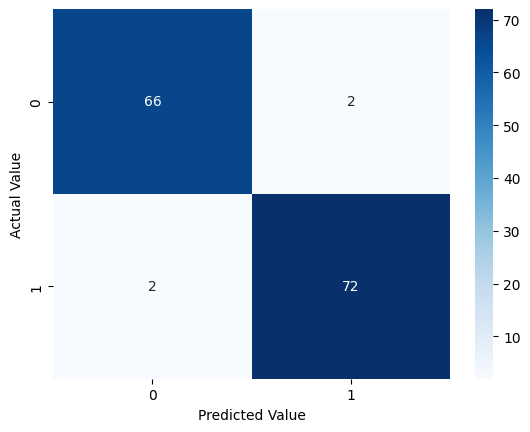

In [48]:
cm = confusion_matrix(ytest,pred)
sns.heatmap(cm, annot = True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [49]:
ytest.value_counts()

diagnosis
M    74
B    68
Name: count, dtype: int64

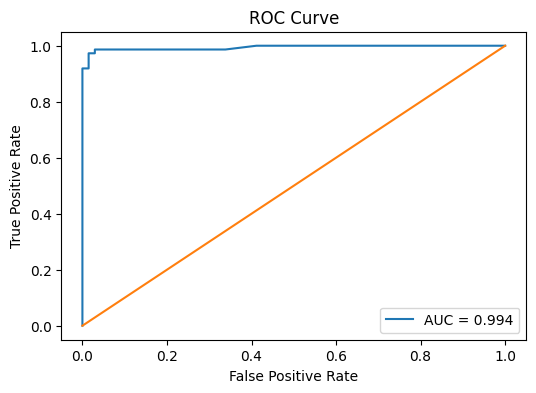

In [52]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Probability of positive class
y_prob = rf.predict_proba(xtest)[:, 1]

# Tell ROC that M is the positive class
fpr, tpr, threshold = roc_curve(ytest, y_prob, pos_label='M')

# AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Random Forest with OOB (Out Of Bag) Score

In [53]:
rf_oob = RandomForestClassifier(oob_score=True)
rf_oob.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [55]:
pred2 = rf_oob.predict(xtest)
pred2

array(['B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M',
       'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'M', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M',
       'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'M', 'M',
       'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B', 'M', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B',
       'B', 'M', 'M', 'M', 'B', 'M', 'M', 'M', 'M', 'M', 'M', 'M'],
      dtype=object)

In [54]:
print("Training accuracy: ",rf_oob.score(xtrain,ytrain))
print("Testing accuracy: ",rf_oob.score(xtest,ytest))

Training accuracy:  1.0
Testing accuracy:  0.9788732394366197


In [56]:
print('Accuracy Score: ',accuracy_score(ytest,pred2))
print('Classification Report: \n',classification_report(ytest,pred2))

Accuracy Score:  0.9788732394366197
Classification Report: 
               precision    recall  f1-score   support

           B       0.99      0.97      0.98        68
           M       0.97      0.99      0.98        74

    accuracy                           0.98       142
   macro avg       0.98      0.98      0.98       142
weighted avg       0.98      0.98      0.98       142



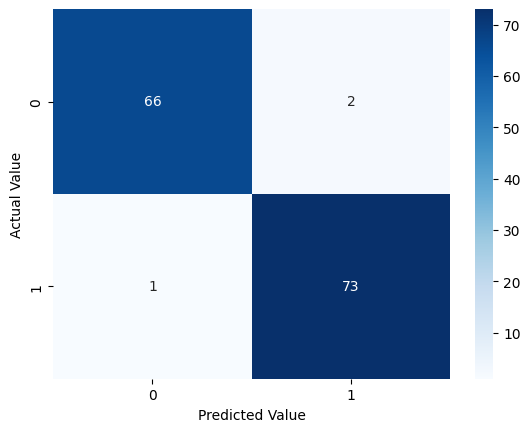

In [57]:
cm = confusion_matrix(ytest,pred2)
sns.heatmap(cm, annot = True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

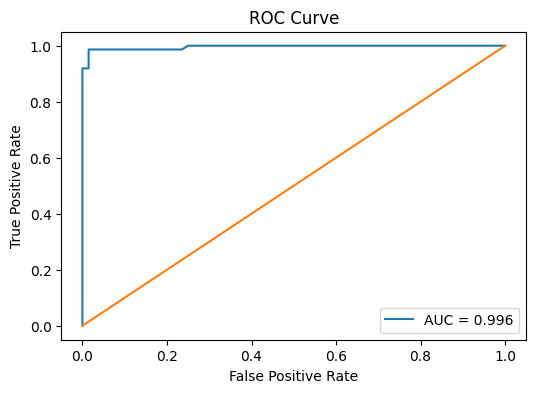

In [58]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Probability of positive class
y_prob = rf_oob.predict_proba(xtest)[:, 1]

# Tell ROC that M is the positive class
fpr, tpr, threshold = roc_curve(ytest, y_prob, pos_label='M')

# AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Pre Pruning Cost Complexity
# Random Forest with Grid Search

In [59]:
param_grid = {
    "n_estimators": [100, 200],
    "criterion": ["gini","entropy"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2,5,10],
    'min_samples_leaf': [1,2,4],
    "max_features": ["auto","sqrt", "log2"]
}

In [61]:
rf_grid_src = GridSearchCV(estimator=RandomForestClassifier(random_state=42, oob_score=True), param_grid = param_grid, cv = 5)

In [62]:
rf_grid_src

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [63]:
rf_grid_src.fit(xtrain,ytrain)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [64]:
print(rf_grid_src.best_params_)

{'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [66]:
y_pred_rn = rf_grid_src.predict(xtest)
y_pred_rn

array(['B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M',
       'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M',
       'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'M', 'M',
       'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B', 'M', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B',
       'B', 'M', 'M', 'M', 'B', 'M', 'M', 'M', 'M', 'M', 'M', 'M'],
      dtype=object)

In [67]:
print("---Accuracy score of Random Forest with Grid Search---")
print("Accuracy score: ",accuracy_score(y_pred_rn, ytest))

---Accuracy score of Random Forest with Grid Search---
Accuracy score:  0.9859154929577465


In [68]:
print("---Calssification report of Random Forest with Grid Search---")
print("Classification Report:\n ",classification_report(y_pred_rn, ytest))

---Calssification report of Random Forest with Grid Search---
Classification Report:
                precision    recall  f1-score   support

           B       0.99      0.99      0.99        68
           M       0.99      0.99      0.99        74

    accuracy                           0.99       142
   macro avg       0.99      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142



# Random Forest with Randomized Search

In [71]:
rf_ran_src = RandomizedSearchCV(estimator = RandomForestClassifier(random_state=42), param_distributions=param_grid,cv=5, n_iter=100)

In [72]:
rf_ran_src.fit(xtrain,ytrain)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [73]:
print(rf_ran_src.best_params_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}


In [75]:
new_ypred = rf_ran_src.predict(xtest)
new_ypred

array(['B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M',
       'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M',
       'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'M', 'M',
       'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B', 'M', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B',
       'B', 'M', 'M', 'M', 'B', 'M', 'M', 'M', 'M', 'M', 'M', 'M'],
      dtype=object)

In [76]:
print("---Accuracy score of Random Forest with Randomized Search---")
print("Accuracy score: ",accuracy_score(new_ypred, ytest))


---Accuracy score of Random Forest with Randomized Search---
Accuracy score:  0.9859154929577465


In [77]:
print("---\nCalssification report of Random Forest with Randomized Search---")
print("Classification Report: ",classification_report(new_ypred, ytest))

---
Calssification report of Random Forest with Randomized Search---
Classification Report:                precision    recall  f1-score   support

           B       0.99      0.99      0.99        68
           M       0.99      0.99      0.99        74

    accuracy                           0.99       142
   macro avg       0.99      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142

